In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from catboost import CatBoostRegressor

In [2]:
train = pd.read_csv("train-test.csv")
validation = pd.read_csv("validation.csv")
december = pd.read_csv("december-chart-inputs.csv")

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("December shape:", december.shape)

Train shape: (48000, 14)
Validation shape: (12000, 13)
December shape: (31, 7)


In [3]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [5]:
train.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [6]:
print("Negative weights:", (train["weight"] < 0).sum())
print("Missing weights:", train["weight"].isnull().sum())
print("Missing market_index:", train["market_index"].isnull().sum())

Negative weights: 292
Missing weights: 300
Missing market_index: 374


In [7]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
december["date"] = pd.to_datetime(december["date"])

In [8]:
print("Training period:", train["date"].min(), "to", train["date"].max())
print("Validation period:", validation["date"].min(), "to", validation["date"].max())

Training period: 2025-01-01 00:00:00 to 2025-10-31 00:00:00
Validation period: 2025-11-01 00:00:00 to 2025-12-31 00:00:00


In [9]:
# Fix negative weights
train["weight"] = train["weight"].abs()
validation["weight"] = validation["weight"].abs()
december["weight"] = december["weight"].abs()

# Calculate medians from training data only
weight_median = train["weight"].median()
market_median = train["market_index"].median()

# Fill missing values
train["weight"] = train["weight"].fillna(weight_median)
validation["weight"] = validation["weight"].fillna(weight_median)
december["weight"] = december["weight"].fillna(weight_median)

train["market_index"] = train["market_index"].fillna(market_median)
validation["market_index"] = validation["market_index"].fillna(market_median)

In [10]:
print("Train missing values:")
print(train[["weight", "market_index"]].isnull().sum())

print("\nValidation missing values:")
print(validation[["weight", "market_index"]].isnull().sum())

print("\nNegative train weights:", (train["weight"] < 0).sum())
print("Negative validation weights:", (validation["weight"] < 0).sum())

Train missing values:
weight          0
market_index    0
dtype: int64

Validation missing values:
weight          0
market_index    0
dtype: int64

Negative train weights: 0
Negative validation weights: 0


In [11]:
def add_features(df):
    df = df.copy()

    df["month"] = df["date"].dt.month
    df["day_of_month"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek

    df["route"] = df["pickup"] + "_" + df["delivery"]

    return df

In [12]:
train = add_features(train)
validation = add_features(validation)
december = add_features(december)

In [13]:
train[
    ["date", "month", "day_of_month", "day_of_week", "route"]
].head()

,date,month,day_of_month,day_of_week,route
0,2025-01-01,1,1,2,Richmond_Baltimore
1,2025-01-01,1,1,2,Richmond_Philadelphia
2,2025-01-01,1,1,2,Philadelphia_Green Bay
3,2025-01-01,1,1,2,Hartford_Atlanta
4,2025-01-01,1,1,2,Dallas_Nashville


In [14]:
train_part = train[
    train["date"] < "2025-09-01"
].copy()

val_part = train[
    train["date"] >= "2025-09-01"
].copy()

print("Training period:")
print(train_part["date"].min(), "to", train_part["date"].max())

print("\nValidation period:")
print(val_part["date"].min(), "to", val_part["date"].max())

print("\nTraining rows:", len(train_part))
print("Validation rows:", len(val_part))

Training period:
2025-01-01 00:00:00 to 2025-08-31 00:00:00

Validation period:
2025-09-01 00:00:00 to 2025-10-31 00:00:00

Training rows: 38477
Validation rows: 9523


In [15]:
X_train = train_part.drop(
    columns=["posted_rate", "load_id", "date"]
)

y_train = train_part["posted_rate"]

X_val = val_part.drop(
    columns=["posted_rate", "load_id", "date"]
)

y_val = val_part["posted_rate"]

In [16]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (38477, 15)
X_val: (9523, 15)


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [18]:
categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [19]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_val)

linear_mae = mean_absolute_error(y_val, linear_predictions)
linear_rmse = mean_squared_error(y_val, linear_predictions) ** 0.5
linear_r2 = r2_score(y_val, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 141.97328182193374
RMSE: 638.4803687524652
R²: 0.8249523758155614


In [20]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_predictions)
rf_rmse = mean_squared_error(y_val, rf_predictions) ** 0.5
rf_r2 = r2_score(y_val, rf_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 159.36580028352404
RMSE: 705.0501135084593
R²: 0.7865475730134037


In [22]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, gb_predictions)
gb_rmse = mean_squared_error(y_val, gb_predictions) ** 0.5
gb_r2 = r2_score(y_val, gb_predictions)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting
MAE: 130.23060670239562
RMSE: 655.9668116187404
R²: 0.8152328085307474


In [23]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_predictions = cat_model.predict(X_val)

cat_mae = mean_absolute_error(y_val, cat_predictions)
cat_rmse = mean_squared_error(y_val, cat_predictions) ** 0.5
cat_r2 = r2_score(y_val, cat_predictions)

print("CatBoost")
print("MAE:", cat_mae)
print("RMSE:", cat_rmse)
print("R²:", cat_r2)

CatBoost
MAE: 112.52318404869162
RMSE: 632.6123528035315
R²: 0.8281551744962138


In [24]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "CatBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae,
        cat_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse,
        cat_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2,
        cat_r2
    ]
})

model_results.sort_values("MAE")

,Model,MAE,RMSE,R2
3,CatBoost,112.523184,632.612353,0.828155
2,Gradient Boosting,130.230607,655.966812,0.815233
0,Linear Regression,141.973282,638.480369,0.824952
1,Random Forest,159.365800,705.050114,0.786548


In [25]:
X_final_train = train.drop(
    columns=["posted_rate", "load_id", "date"]
)

y_final_train = train["posted_rate"]

X_final_validation = validation.drop(
    columns=["load_id", "date"]
)

In [26]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

final_model.fit(
    X_final_train,
    y_final_train,
    cat_features=[
        "pickup",
        "delivery",
        "equipment",
        "route"
    ]
)

CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [27]:
final_predictions = final_model.predict(X_final_validation)

print("Number of predictions:", len(final_predictions))

Number of predictions: 12000


In [28]:
submission = pd.DataFrame({
    "load_id": validation["load_id"],
    "predicted_rate": final_predictions
})

submission.head()

,load_id,predicted_rate
0,TE-000001,885.399751
1,TE-000002,4967.199950
2,TE-000003,5208.943655
3,TE-000004,4062.006465
4,TE-000005,1911.626718


In [29]:
print(submission.shape)
print(submission.isnull().sum())
print((submission["predicted_rate"] <= 0).sum())

(12000, 2)
load_id           0
predicted_rate    0
dtype: int64
0


In [30]:
submission.to_csv(
    "validation_predictions.csv",
    index=False
)

In [31]:
dec_features = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "month",
    "day_of_month",
    "day_of_week",
    "route"
]

In [32]:
X_dec_train = train[dec_features]
y_dec_train = train["posted_rate"]

X_december = december[dec_features]

In [33]:
december_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

december_model.fit(
    X_dec_train,
    y_dec_train,
    cat_features=[
        "pickup",
        "delivery",
        "equipment",
        "route"
    ]
)

CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [34]:
december["predicted_rate"] = december_model.predict(X_december)

In [35]:
december_output = december[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

december_output.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,857.559054
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,896.125370
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,895.320419
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,894.686690
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,877.338450


In [36]:
december_output.to_csv(
    "december_predictions.csv",
    index=False
)

In [37]:
print("Validation predictions:", submission.shape)
print("December predictions:", december_output.shape)

print(
    "Invalid validation rates:",
    (submission["predicted_rate"] <= 0).sum()
)

print(
    "Invalid December rates:",
    (december_output["predicted_rate"] <= 0).sum()
)

Validation predictions: (12000, 2)
December predictions: (31, 7)
Invalid validation rates: 0
Invalid December rates: 0


In [38]:
!python score.py --predictions validation_predictions.csv --december-predictions december_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


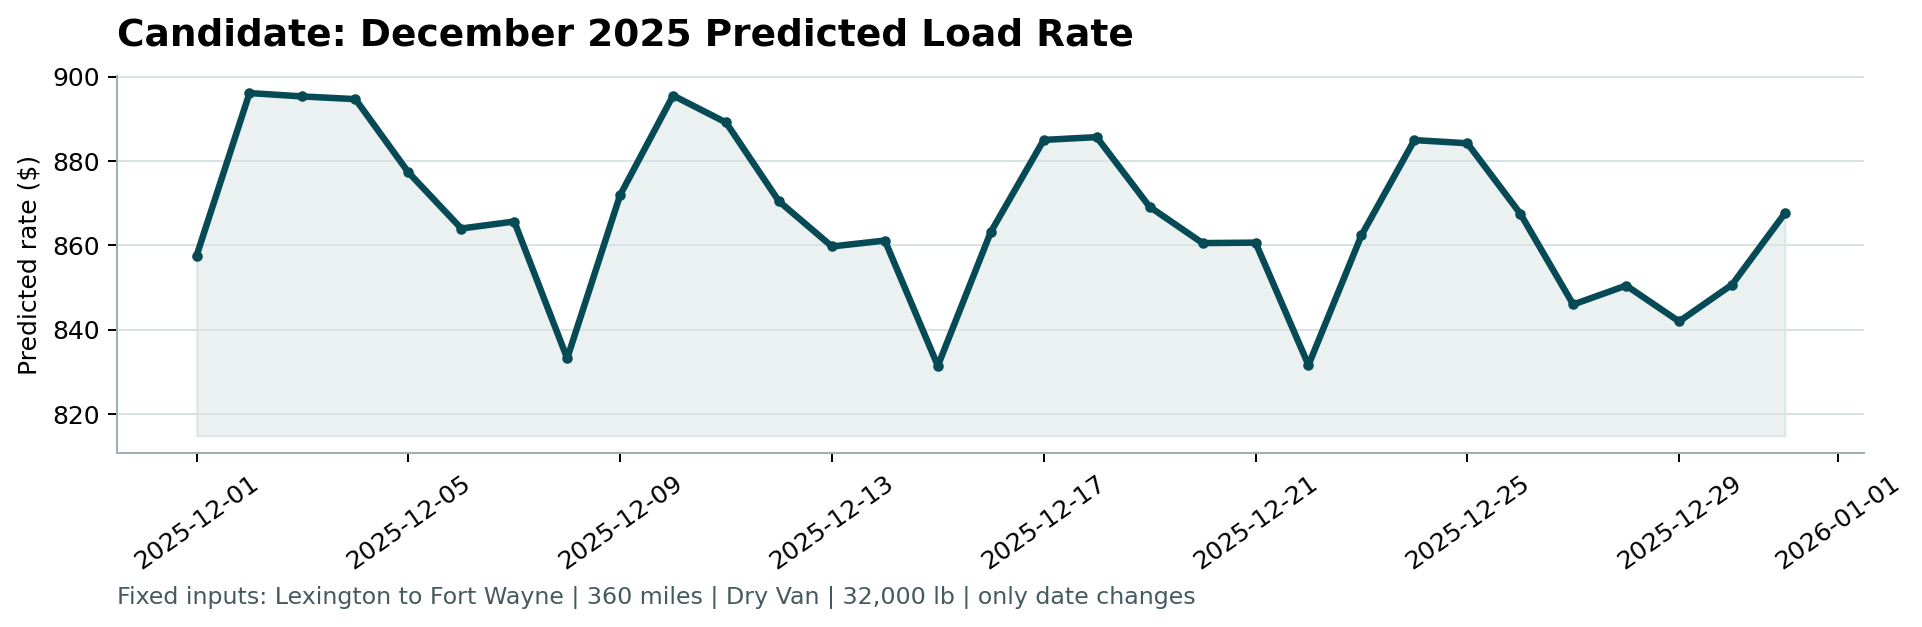

In [39]:
from IPython.display import Image, display

display(Image(filename="scorer_results/candidate_december.png"))